In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path)

    # Convert first column to datetime
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])

    # Rename the date column
    df.rename(columns={date_col: 'Date'}, inplace=True)

    # Set index
    df.set_index('Date', inplace=True)

    # Identify numeric columns (excluding Date)
    numeric_cols = df.columns.difference(['Date'])

    # Replace missing values ('.' → NaN) and convert to numeric
    df[numeric_cols] = df[numeric_cols].replace('.', pd.NA).astype(float)

    # Only select data between 2000-01-01 and 2024-12-31
    df = df.loc['2000-01-01':'2024-12-31']

    # Drop NaN values
    df.dropna(inplace=True)

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/data.csv")
df.head()

,USDJPY_Close,USDJPY1D_Close,_VIXD_Close
Date,,,
2000-01-31,107.36,106.37,26.20
2000-02-29,110.19,109.31,25.59
2000-03-31,102.75,102.07,27.21
2000-04-30,108.16,107.17,28.86
2000-05-31,107.61,106.83,26.57


In [4]:
# Rename columns
df = df.rename(columns={'USDJPY_Close': 'spot_rate', 'USDJPY1D_Close': '1month_forward_rate', '_VIXD_Close': 'vix'})

In [5]:
# Count NaN values in each column
print(f"The number of non-NaN values: \n{df.count()}")
print("\n")
print(f"The number of NaN values: \n{df.isna().sum()}")

The number of non-NaN values: 
spot_rate              285
1month_forward_rate    285
vix                    285
dtype: int64


The number of NaN values: 
spot_rate              0
1month_forward_rate    0
vix                    0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 285 entries, 2000-01-31 to 2024-03-31
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   spot_rate            285 non-null    float64
 1   1month_forward_rate  285 non-null    float64
 2   vix                  285 non-null    float64
dtypes: float64(3)
memory usage: 8.9 KB


In [7]:
df.describe()

,spot_rate,1month_forward_rate,vix
count,285.000000,285.000000,285.000000
mean,110.217404,109.688118,20.494491
std,15.104993,14.586309,8.450387
min,76.190000,76.250000,9.510000
25%,103.420000,103.210000,13.950000
50%,110.190000,109.784064,18.230000
75%,118.440000,118.450000,24.510000
max,151.670000,151.515000,59.890000


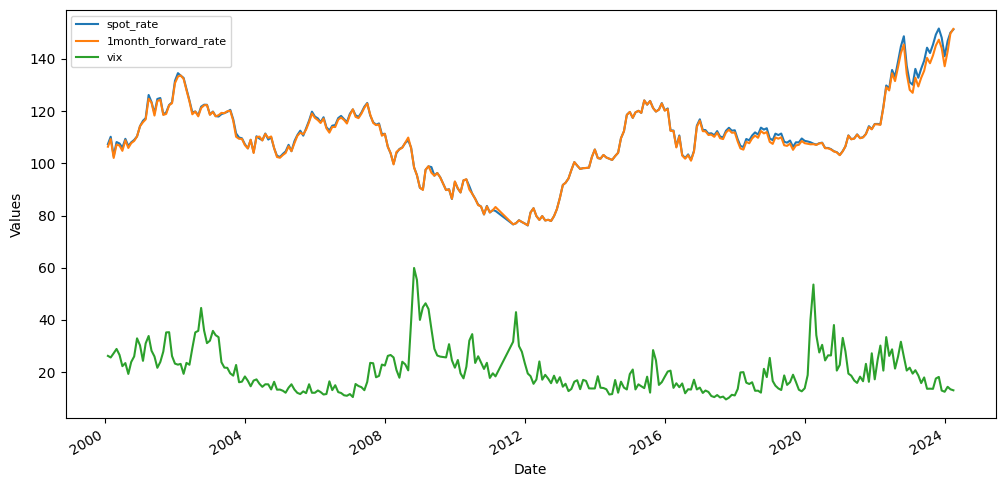

In [8]:
df.plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left', prop={'size': 8});